## Preparing data for modeling

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, RepeatedStratifiedKFold, StratifiedKFold, cross_validate, cross_val_predict, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [87]:
df = pd.read_csv(r'C:\Users\grzeg\Portfolio\Credit-Risk-Prediction\south_german_credit\data\South German Credit.asc', delimiter = ' ')

In [89]:
df

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,24,2,3,1987,1,3,2,3,1,...,1,21,3,1,1,2,1,1,2,0
996,1,24,2,0,2303,1,5,4,3,2,...,1,45,3,2,1,3,2,1,2,0
997,4,21,4,0,12680,5,5,4,3,1,...,4,30,3,3,1,4,2,2,2,0
998,2,12,2,3,6468,5,1,2,3,1,...,4,52,3,2,1,4,2,2,2,0


In [91]:
df['credit_risk'] = df['credit_risk'].map({0:1, 1:0})

In [93]:
df['credit_risk'].value_counts()

credit_risk
0    700
1    300
Name: count, dtype: int64

In [95]:
df['amount'] = np.log(df['amount'])

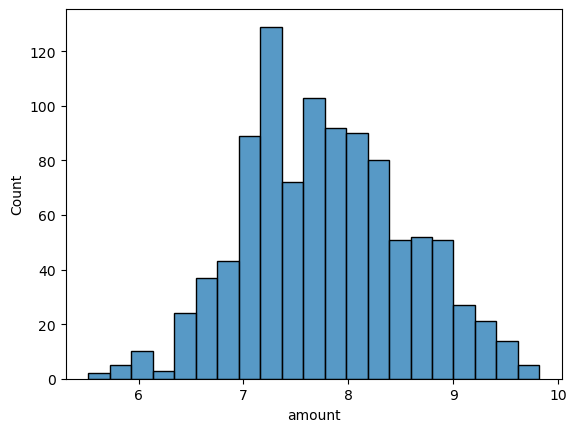

In [97]:
sns.histplot(data = df, x = 'amount');

In [99]:
num = ['duration', 'amount', 'age']
cat = df.drop(num + ['credit_risk'], axis = 1).columns

In [101]:
X = df.drop('credit_risk', axis = 1)
y = df['credit_risk']

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

In [105]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

In [107]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

## Base models + choosing best feature sets

In [141]:
algos = [LogisticRegression(random_state = 42), 
         KNeighborsClassifier(), 
         DecisionTreeClassifier(random_state =42), 
         RandomForestClassifier(random_state =42), 
         XGBClassifier(random_state =42), 
         SVC(random_state = 42, probability=True)]

In [143]:
from sklearn.metrics import make_scorer, recall_score, precision_score, roc_auc_score, average_precision_score

In [145]:
scoring = {
    'roc_auc':'roc_auc',
    'avg_precision':'average_precision',
    "recall_1": make_scorer(recall_score, pos_label=1),
    "recall_0": make_scorer(recall_score, pos_label=0),
    "precision_1": make_scorer(precision_score, pos_label=1),
}

In [147]:
names = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVM']

In [149]:
feature_sets = {
    "with_all": num + list(cat),
    "without_job": num + [col for col in cat if col != "job"],
    "without_credit_history": num +[col for col in cat if col != "credit_history"],
    "without_personal_status": num + [col for col in cat if col !="personal_status"],
    "without_job&credit_history": num + [col for col in cat if col != "job" and col != "credit_history"],
    "without_job&personal_status": num + [col for col in cat if col != "job" and col != "personal_status"],
    "without_credit_history&personal_staus": num + [col for col in cat if col != "credit_history" and col != "personal_status"],
    "without_job&credit_history&personal_status": num + [col for col in cat if col != "job" and col != "credit_history" and col != "personal_status"]
}

In [159]:
results = []
for c_names, columns in feature_sets.items():
    numeric = [col for col in columns if col in num]
    categorical = [col for col in columns if col in cat]
    transformer = ColumnTransformer([('num', StandardScaler(), numeric), ('cat', OneHotEncoder(drop = 'first'), categorical)])
    for algo, name in zip(algos, names):
        pipe = Pipeline([('transformer', transformer), ('clf',algo)])
        c_v = cross_validate(pipe, X_train[columns], y_train, scoring = scoring, cv = cv, return_train_score = True, n_jobs = -1)
        results.append({'algo': name,
                        'type': c_names,
                        'roc_auc': c_v['test_roc_auc'].mean(),
                        'avg_precision': c_v['test_avg_precision'].mean(),
                        'recall_1': c_v['test_recall_1'].mean(),
                        'recall_0': c_v['test_recall_0'].mean(),
                        'precision_1': c_v['test_precision_1'].mean()})

In [163]:
pd.DataFrame(results).sort_values(['algo', 'roc_auc', 'avg_precision'], ascending = [True, False, False])

,algo,type,roc_auc,avg_precision,recall_1,recall_0,precision_1
32,Decision Tree,without_job&personal_status,0.619643,0.379535,0.483333,0.755952,0.459229
20,Decision Tree,without_personal_status,0.619444,0.378378,0.476389,0.762500,0.461810
38,Decision Tree,without_credit_history&personal_staus,0.618849,0.377362,0.484722,0.752976,0.460278
44,Decision Tree,without_job&credit_history&personal_status,0.617758,0.378570,0.465278,0.770238,0.468201
2,Decision Tree,with_all,0.616270,0.376865,0.469444,0.763095,0.459104
8,Decision Tree,without_job,0.610714,0.370686,0.483333,0.738095,0.443008
14,Decision Tree,without_credit_history,0.608333,0.369006,0.466667,0.750000,0.446028
26,Decision Tree,without_job&credit_history,0.602480,0.366231,0.455556,0.749405,0.441346
7,KNN,without_job,0.701277,0.454323,0.383333,0.838690,0.507620
1,KNN,with_all,0.692237,0.457559,0.372222,0.849405,0.515534


In [58]:
def overfitting(df:pd.DataFrame):
    return{"roc_auc_mean": df["train_roc_auc"].mean() - df["test_roc_auc"].mean(),
          'pr-auc_mean': df['train_avg_precision'].mean() - df['test_avg_precision'].mean() ,
          "recall_1_mean": df["train_recall_1"].mean() - df["test_recall_1"].mean(),
          "recall_0_mean": df["train_recall_0"].mean() - df["test_recall_0"].mean(),
          "precision_1_mean": df["train_precision_1"].mean() - df["test_precision_1"].mean()}

## Nested Cross Validation

In [197]:
from scipy.stats import loguniform, uniform, randint

In [199]:
pd_rl = {'clf__penalty': ['l1', 'l2', 'elasticnet'],
        'clf__C': loguniform(1e-3, 1e3),
         'clf__l1_ratio': uniform(0,1)
        }
pd_knn = {'clf__n_neighbors': randint(1, 51),
          "clf__weights": ["uniform", "distance"],
          "clf__p": randint(1, 2)
         }
pd_dt = {'clf__max_depth': randint(1,16),
         'clf__min_samples_split': randint(2,16),
         'clf__min_samples_leaf': randint(1,21),
         'clf__ccp_alpha':loguniform(1e-5, 1e-1),
         'clf__max_leaf_nodes': randint(2,16)
        }
pd_rf = {'clf__n_estimators': randint(50, 501),
         'clf__max_depth': randint(1,10),
         'clf__min_samples_leaf': randint(1,16),
         'clf__max_features': ['sqrt','log2']
        }
pd_xgb = {'clf__colsample_bytree': uniform(0, 1),
          'clf__subsample': uniform(0, 1),
          'clf__learning_rate': loguniform(1e-4, 1e0),
          'clf__max_depth': randint(1,10),
          'clf__n_estimators': randint(50, 501),
          'clf__reg_alpha': loguniform(1e-4, 1e1),
          'clf__reg_lambda': loguniform(1e-4, 1e2),
          'clf__gamma': loguniform(1e-8, 1e1)
         }
pd_svm = {'clf__kernel': ['rbf', 'poly', 'sigmoid'],
          'clf__C': loguniform(1e-3, 1e3),
          'clf__gamma': loguniform(1e-4, 1e0),
          'clf__degree': randint(2,6)
         }
param_distributions = [pd_rl, pd_knn, pd_dt, pd_rf, pd_xgb, pd_svm]

In [201]:
X = df.drop(['credit_risk', 'job'], axis = 1)
y = df['credit_risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

In [203]:
from sklearn.metrics import make_scorer, recall_score, precision_score, roc_auc_score, average_precision_score

In [205]:
scoring = {
    'roc_auc':'roc_auc',
    'avg_precision':'average_precision',
    "recall_1": make_scorer(recall_score, pos_label=1),
    "recall_0": make_scorer(recall_score, pos_label=0),
    "precision_1": make_scorer(precision_score, pos_label=1),
}

In [207]:
names = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVM']

In [209]:
from collections import Counter

In [211]:
counter = Counter(y_train)

In [213]:
scale_pos_weight = counter[0]/counter[1]

In [215]:
inner_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
outer_cv = RepeatedStratifiedKFold(n_splits = 5, n_repeats = 3, random_state = 2)

In [217]:
n_iters = [50, 50, 50, 200, 300, 200]

In [219]:
def training(pipe, results):
    
    for model, param, n, name in zip(pipe, param_distributions, n_iters, results.keys()):
        for fold_id, (train, test) in enumerate(outer_cv.split(X_train, y_train)):
            X_tr, X_te = X_train.iloc[train], X_train.iloc[test]
            y_tr, y_te = y_train.iloc[train], y_train.iloc[test]
            r_s = RandomizedSearchCV(estimator = model, param_distributions = param, n_iter = n, scoring = scoring, n_jobs = -1, refit = 'roc_auc', cv = inner_cv, random_state = 42, return_train_score = True) 
            r_s.fit(X_tr, y_tr)
            best_model = r_s.best_estimator_
            best_params = r_s.best_params_
            y_pred = r_s.predict(X_te)
            p_te = r_s.predict_proba(X_te)[:,1]
            results[name].append({
            'fold': fold_id,
            'params': best_params,
            'roc_auc': roc_auc_score(y_te, p_te),
            'avg_precision': average_precision_score(y_te, p_te),
            'recall_1': recall_score(y_te, y_pred, pos_label=1),
            'precision_1': precision_score(y_te, y_pred, pos_label=1, zero_division=0),
            'recall_0': recall_score(y_te, y_pred, pos_label=0)})

In [221]:
numeric = ['age', 'amount', 'duration']
categorical = df.drop(numeric + ['credit_risk'] + ['job'], axis = 1).columns

In [223]:
transformer = ColumnTransformer([('num', StandardScaler(), numeric), ('cat', OneHotEncoder(drop = 'first'), categorical)])

### Class_weight = 'balanced' models

In [76]:
algos_cw = [LogisticRegression(random_state = 42, class_weight = 'balanced', solver = 'saga'), 
         KNeighborsClassifier(), 
         DecisionTreeClassifier(random_state =42, class_weight = 'balanced'), 
         RandomForestClassifier(random_state =42, class_weight = 'balanced'), 
         XGBClassifier(random_state =42, scale_pos_weight = scale_pos_weight), 
         SVC(random_state = 42, probability=True, class_weight = 'balanced')]

In [78]:
pipes_cw = []
for algo in algos_cw:
    pipes_cw.append(Pipeline([('transformer', transformer), ('clf', algo)]))

In [80]:
results_cw = {
    'Logistic Regression_cw':[],
    'KNN_cw':[], 
    'Decision Tree_cw':[], 
    'Random Forest_cw':[], 
    'XGBoost_cw':[], 
    'SVM_cw': []   
}

In [82]:
training(pipes_cw, results_cw)

C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_log

In [86]:
import joblib
joblib.dump(results_cw, 'C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/cw_nested_cv_results2.joblib')

['C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/cw_nested_cv_results2.joblib']

### Undersampling models

In [153]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state = 42)

In [155]:
algos_rus = [LogisticRegression(random_state = 42, solver = 'saga'), 
         KNeighborsClassifier(), 
         DecisionTreeClassifier(random_state =42), 
         RandomForestClassifier(random_state =42), 
         XGBClassifier(random_state =42), 
         SVC(random_state = 42, probability=True)]

In [157]:
transformer = ColumnTransformer([('num', StandardScaler(), numeric), ('cat', OneHotEncoder(drop = 'first'), categorical)]) 

In [159]:
pipes_rus = []
for model in algos_rus:
    pipes_rus.append(Pipeline(steps = [('pre', transformer), ('rus', rus), ('clf', model)]))

In [161]:
results_rus = {
    'Logistic Regression_rus':[],
    'KNN_rus':[], 
    'Decision Tree_rus':[], 
    'Random Forest_rus':[], 
    'XGBoost_rus':[], 
    'SVM_rus': []   
}

In [163]:
training(pipes_rus, results_rus)

C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175:

In [167]:
import joblib
joblib.dump(results_rus, 'C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/rus_nested_cv_results2.joblib')

['C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/rus_nested_cv_results2.joblib']

### Oversampling models

In [169]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state = 42)

In [171]:
algos_ros = [LogisticRegression(random_state = 42, solver = 'saga'), 
         KNeighborsClassifier(), 
         DecisionTreeClassifier(random_state =42), 
         RandomForestClassifier(random_state =42), 
         XGBClassifier(random_state =42), 
         SVC(random_state = 42, probability=True)]

In [173]:
pipes_ros = []
for model in algos_ros:
    pipes_ros.append(Pipeline(steps = [('pre', transformer), ('ros', ros), ('clf', model)]))

In [175]:
results_ros = {
    'Logistic Regression_ros':[],
    'KNN_ros':[], 
    'Decision Tree_ros':[], 
    'Random Forest_ros':[], 
    'XGBoost_ros':[], 
    'SVM_ros': []   
}

In [177]:
training(pipes_ros, results_ros)

C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\grzeg\anaconda3\Lib\site-packages\sklearn\linear_model\_sag

In [179]:
import joblib
joblib.dump(results_ros, 'C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/ros_nested_cv_results2.joblib')

['C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/ros_nested_cv_results2.joblib']

## Results summary

In [25]:
import joblib
results_cw = joblib.load('C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/cw_nested_cv_results2.joblib')
results_rus = joblib.load('C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/rus_nested_cv_results2.joblib')
results_ros = joblib.load('C:/Users/grzeg/Portfolio/Credit-Risk-Prediction/south_german_credit/results/ros_nested_cv_results2.joblib')

In [27]:
metrics = ['roc_auc', 'avg_precision', 'recall_1', 'precision_1', 'recall_0']

In [29]:
def summary_df(results, metrics):
    summary = {}
    for name in results.keys():
        summary[name] = {}
        for metric in metrics:
            val = []
            for fold in range(15):
                val.append(results[name][fold][metric])
            summary[name][metric] = val
    mean_df = {}
    for name in results.keys():
        mean_df[name] = {}
        for metric in metrics:
            mean_df[name][metric+'_mean'] = np.mean(summary[name][metric])
            mean_df[name][metric+'_std'] = np.std(summary[name][metric])
    return pd.DataFrame(mean_df)

In [31]:
cw = summary_df(results_cw, metrics).T
rus = summary_df(results_rus, metrics).T
ros = summary_df(results_ros, metrics).T
combined_results = pd.concat([cw,rus,ros])

In [33]:
x = combined_results.sort_values('recall_1_mean', ascending = False)

In [193]:
x[(x['precision_1_mean']>0.5)&(x['recall_1_mean'] >0.7)]

,roc_auc_mean,roc_auc_std,avg_precision_mean,avg_precision_std,recall_1_mean,recall_1_std,precision_1_mean,precision_1_std,recall_0_mean,recall_0_std
Logistic Regression_cw,0.773611,0.038896,0.596605,0.069939,0.713889,0.065204,0.522587,0.041077,0.719643,0.036422
SVM_cw,0.772129,0.029838,0.596790,0.052409,0.709722,0.070738,0.515614,0.023293,0.714286,0.028978
Logistic Regression_ros,0.774405,0.038732,0.595998,0.069128,0.708333,0.063647,0.528469,0.043414,0.727976,0.037296
SVM_ros,0.773072,0.033064,0.598255,0.063703,0.705556,0.080460,0.517477,0.033658,0.717857,0.035235


## Final hyperparameters tuning

In [225]:
pd_rl = {'clf__penalty': ['l1', 'l2', 'elasticnet'],
        'clf__C': loguniform(1e-3, 1e3),
         'clf__l1_ratio': uniform(0,1)
        }

In [227]:
transformer = ColumnTransformer([('num', StandardScaler(), numeric), ('cat', OneHotEncoder(drop = 'first'), categorical)])

In [229]:
pipe = Pipeline(steps = [('pre', transformer), ('clf', LogisticRegression(random_state = 42, class_weight = 'balanced', solver = 'saga'))])

In [231]:
cv = RepeatedStratifiedKFold(n_splits = 5, n_repeats = 5, random_state = 42)

In [233]:
model = RandomizedSearchCV(estimator = pipe, param_distributions = pd_rl, n_iter = 100, cv = cv, scoring = scoring, n_jobs = -1, refit = False, random_state = 42, return_train_score=True)

In [237]:
model.fit(X_train, y_train)

RandomizedSearchCV(cv=RepeatedStratifiedKFold(n_repeats=5, n_splits=5, random_state=42),
                   estimator=Pipeline(steps=[('pre',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['age',
                                                                                'amount',
                                                                                'duration']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='first'),
                                                                               Index(['status', 'credit_history', 'purpose', 'savings', 'employment_duration',
       'installment_rate', 'personal_status'...
                                                         'elasticnet']},
                   random_state=42, refit=False, return_train_score=True,
                   scoring={'avg_precision': 'average_precision',
                            'precision_1': make_scorer(precision_score, response_method='predict', pos_label=1),
                            'recall_0': make_scorer(recall_score, response_method='predict', pos_label=0),
                            'recall_1': make_scorer(recall_score, response_method='predict', pos_label=1),
                            'roc_auc': 'roc_auc'})

In [263]:
results = pd.DataFrame(model.cv_results_)

In [333]:
x = results[[col for col in pd.DataFrame(model.cv_results_) if 'mean_test' in col or 'mean_train' in col or 'std_test' in col or 'std_train' in col]]

In [335]:
x

,mean_test_roc_auc,std_test_roc_auc,mean_train_roc_auc,std_train_roc_auc,mean_test_avg_precision,std_test_avg_precision,mean_train_avg_precision,std_train_avg_precision,mean_test_recall_1,std_test_recall_1,mean_train_recall_1,std_train_recall_1,mean_test_recall_0,std_test_recall_0,mean_train_recall_0,std_train_recall_0,mean_test_precision_1,std_test_precision_1,mean_train_precision_1,std_train_precision_1
0,0.772999,0.016778,0.809250,0.005376,0.588823,0.032145,0.635219,0.015782,0.729167,0.050346,0.769167,0.012123,0.676071,0.035850,0.692143,0.014423,0.492010,0.027676,0.517318,0.010714
1,0.774836,0.026391,0.851278,0.005842,0.604732,0.049358,0.711571,0.016781,0.691667,0.056826,0.787292,0.015707,0.724643,0.034597,0.760893,0.010533,0.519492,0.032948,0.585385,0.013074
2,0.500000,0.000000,0.500000,0.000000,0.300000,0.000000,0.300000,0.000000,0.560000,0.496387,0.560000,0.496387,0.440000,0.496387,0.440000,0.496387,0.168000,0.148916,0.168000,0.148916
3,0.778743,0.025401,0.850886,0.005830,0.607510,0.047717,0.710474,0.016598,0.700000,0.054962,0.786458,0.017116,0.728214,0.033031,0.762232,0.010280,0.525638,0.032945,0.586475,0.012461
4,0.730618,0.035195,0.753886,0.004697,0.538698,0.049198,0.552758,0.008547,0.619167,0.073721,0.656250,0.019654,0.707857,0.036116,0.715536,0.011224,0.476443,0.041814,0.497240,0.010265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.739769,0.032603,0.765394,0.004680,0.548548,0.046936,0.566702,0.009363,0.644167,0.078156,0.684792,0.012937,0.710000,0.039133,0.718125,0.010033,0.488243,0.042440,0.510196,0.009808
96,0.783326,0.022826,0.835193,0.005231,0.606800,0.035358,0.679599,0.014767,0.720833,0.049301,0.773750,0.013904,0.719286,0.034909,0.741786,0.011464,0.525175,0.031745,0.562383,0.010554
97,0.774546,0.026589,0.851295,0.005845,0.604628,0.049579,0.711562,0.016785,0.690833,0.057033,0.787708,0.015885,0.724643,0.034597,0.761518,0.011164,0.519186,0.032502,0.586169,0.013858
98,0.500000,0.000000,0.500000,0.000000,0.300000,0.000000,0.300000,0.000000,0.680000,0.466476,0.680000,0.466476,0.320000,0.466476,0.320000,0.466476,0.204000,0.139943,0.204000,0.139943


In [339]:
x[(x['mean_test_precision_1'] > 0.5)&( x['mean_test_recall_1'] > 0.7)].sort_values('mean_test_recall_1', ascending = False).head(10)

,mean_test_roc_auc,std_test_roc_auc,mean_train_roc_auc,std_train_roc_auc,mean_test_avg_precision,std_test_avg_precision,mean_train_avg_precision,std_train_avg_precision,mean_test_recall_1,std_test_recall_1,mean_train_recall_1,std_train_recall_1,mean_test_recall_0,std_test_recall_0,mean_train_recall_0,std_train_recall_0,mean_test_precision_1,std_test_precision_1,mean_train_precision_1,std_train_precision_1
32,0.774278,0.019321,0.806902,0.004572,0.590498,0.033423,0.630155,0.013631,0.726667,0.054109,0.762708,0.012155,0.688929,0.038769,0.704911,0.011434,0.501636,0.032939,0.525700,0.009136
7,0.784814,0.022885,0.841835,0.005820,0.608863,0.038533,0.691284,0.015829,0.725833,0.052928,0.780625,0.014000,0.720714,0.038756,0.746786,0.012145,0.528547,0.033074,0.569391,0.011613
39,0.780164,0.022951,0.827047,0.005182,0.600546,0.034581,0.664176,0.014276,0.725000,0.057130,0.768750,0.011024,0.715714,0.037259,0.735893,0.012591,0.523581,0.032015,0.555276,0.011102
9,0.785112,0.022701,0.840876,0.006164,0.608046,0.040053,0.688628,0.016581,0.724167,0.054096,0.777292,0.013199,0.715714,0.035596,0.741161,0.013099,0.523097,0.031883,0.562976,0.012742
85,0.783824,0.023759,0.844780,0.005987,0.605944,0.042528,0.695306,0.017091,0.723333,0.048777,0.780417,0.012984,0.718929,0.039377,0.748839,0.011261,0.526246,0.035456,0.571297,0.010305
42,0.777321,0.022865,0.821704,0.005015,0.594603,0.033820,0.654068,0.013590,0.722500,0.055815,0.765417,0.011737,0.713571,0.037790,0.732679,0.011646,0.520868,0.034921,0.551170,0.010717
81,0.783750,0.023197,0.836567,0.005269,0.607716,0.035801,0.682401,0.014923,0.721667,0.048548,0.775625,0.012318,0.720714,0.034024,0.743214,0.011987,0.526689,0.031614,0.564372,0.011056
8,0.784613,0.022672,0.840326,0.005498,0.609425,0.037219,0.689416,0.015297,0.720833,0.057434,0.778958,0.015456,0.721429,0.038216,0.746607,0.011813,0.527306,0.035493,0.568667,0.012439
96,0.783326,0.022826,0.835193,0.005231,0.606800,0.035358,0.679599,0.014767,0.720833,0.049301,0.773750,0.013904,0.719286,0.034909,0.741786,0.011464,0.525175,0.031745,0.562383,0.010554
52,0.784754,0.022879,0.841354,0.005464,0.610249,0.037880,0.691755,0.015167,0.719167,0.057470,0.778958,0.013668,0.722500,0.038376,0.747054,0.011671,0.527673,0.036220,0.569107,0.011732
